# Retail Demand Forecasting — Data Preprocessing & SARIMA Modeling
**Project:** Web-based Retail Demand Prediction System  
**Model:** SARIMA (Seasonal AutoRegressive Integrated Moving Average)  
**Pipeline:** Ingestion → Cleaning → Imputation → Outlier Handling → Feature Engineering → Normalization → Modeling → Evaluation

## 1. Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import holidays
import os
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Ingestion

Accepts CSV or XLSX. Update `FILE_PATH` to the path of your dataset.  
Expected columns: `Order Date`, `Sales`, `Quantity`, `Profit`, `Discount`, `Category`, `Sub-Category`, `Region`, `Segment`.

In [3]:
# ────────────────────────────────────────────────────────────────────────────
FILE_PATH = '../Sample - Superstore.csv'
# ────────────────────────────────────────────────────────────────────────────

def load_data(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[-1].lower()
    if ext == '.csv':
        df = pd.read_csv(path, encoding='latin-1')
    elif ext in ('.xlsx', '.xls'):
        df = pd.read_excel(path)
    else:
        raise ValueError(f'Unsupported file format: {ext}')
    return df

df_raw = load_data(FILE_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head()

Shape: (9994, 21)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.0000,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.0000,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.0000,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.4500,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.2000,2.5164


## 3. Initial Exploratory Data Analysis

In [4]:
print('=== Data Types ===')
print(df_raw.dtypes)
print('\n=== Missing Values ===')
print(df_raw.isnull().sum())
print('\n=== Basic Statistics ===')
df_raw.describe()

=== Data Types ===
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

=== B

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.0000,9994.0000,9994.0000,9994.0000,9994.0000,9994.0000
mean,4997.5000,55190.3794,229.8580,3.7896,0.1562,28.6569
std,2885.1636,32063.6934,623.2451,2.2251,0.2065,234.2601
min,1.0000,1040.0000,0.4440,1.0000,0.0000,-6599.9780
25%,2499.2500,23223.0000,17.2800,2.0000,0.0000,1.7288
50%,4997.5000,56430.5000,54.4900,3.0000,0.2000,8.6665
75%,7495.7500,90008.0000,209.9400,5.0000,0.2000,29.3640
max,9994.0000,99301.0000,22638.4800,14.0000,0.8000,8399.9760


In [5]:
print('=== Duplicate Rows ===')
print(f'Total duplicates: {df_raw.duplicated().sum()}')

=== Duplicate Rows ===
Total duplicates: 0


## 4. Data Cleaning

### 4a. Remove Duplicate Rows

In [6]:
df = df_raw.copy()
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Rows before: {before} | Rows after: {after} | Removed: {before - after}')

Rows before: 9994 | Rows after: 9994 | Removed: 0


### 4b. Drop Irrelevant Columns

In [7]:
# Row ID is a sequential index; Postal Code and Customer Name carry no
# predictive signal for time-series demand forecasting.
COLS_TO_DROP = ['Row ID', 'Postal Code', 'Customer Name', 'Country']
existing_drop = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=existing_drop, inplace=True)
print(f'Dropped columns: {existing_drop}')
print(f'Remaining columns: {df.columns.tolist()}')

Dropped columns: ['Row ID', 'Postal Code', 'Customer Name', 'Country']
Remaining columns: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


### 4c. Parse Date Columns

In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], infer_datetime_format=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  infer_datetime_format=True)
print('Date columns parsed.')
print(df[['Order Date', 'Ship Date']].dtypes)

Date columns parsed.
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


## 5. Data Imputation

Strategy:
- **Numeric columns** with ≤ 5 consecutive NaNs → Linear Interpolation  
- **Numeric columns** with remaining NaNs → Column mean  
- **Categorical columns** → Forward-fill then mode

In [9]:
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Sort by Order Date so interpolation is chronologically meaningful
df.sort_values('Order Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# --- Numeric imputation -------------------------------------------------
df[numeric_cols] = df[numeric_cols].interpolate(method='linear', limit=5, limit_direction='both')
for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        col_mean = df[col].mean()
        df[col].fillna(col_mean, inplace=True)
        print(f'  [{col}] filled {missing} remaining NaNs with mean = {col_mean:.4f}')

# --- Categorical imputation ---------------------------------------------
for col in categorical_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        df[col] = df[col].fillna(method='ffill')
        if df[col].isnull().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
        print(f'  [{col}] imputed {missing} missing values')

print(f'\nRemaining nulls: {df.isnull().sum().sum()}')


Remaining nulls: 0


## 6. Outlier Handling

Method: **IQR Capping (Winsorization)** on `Sales`, `Quantity`, and `Profit`.  
Outliers are capped (not dropped) to preserve temporal continuity required by SARIMA.

In [10]:
def iqr_cap(series: pd.Series, factor: float = 1.5) -> pd.Series:
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
    return series.clip(lower=lower, upper=upper)

OUTLIER_COLS = ['Sales', 'Quantity', 'Profit']
for col in OUTLIER_COLS:
    if col in df.columns:
        before_std = df[col].std()
        df[col] = iqr_cap(df[col])
        after_std  = df[col].std()
        print(f'[{col}] std before={before_std:.4f} | after={after_std:.4f}')

[Sales] std before=623.2451 | after=168.8042
[Quantity] std before=2.2251 | after=2.1026
[Profit] std before=234.2601 | after=29.4865


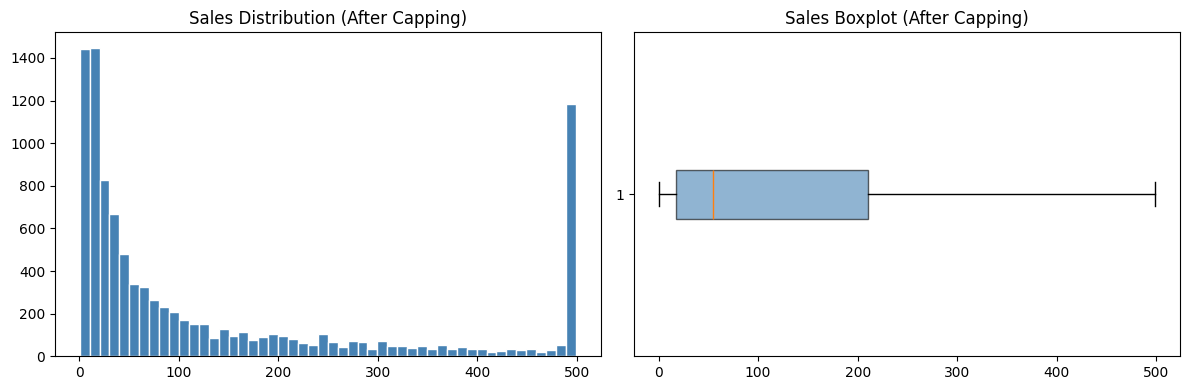

In [11]:
# Visual check — distribution of Sales after capping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sales Distribution (After Capping)')
axes[1].boxplot(df['Sales'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Sales Boxplot (After Capping)')
plt.tight_layout()
plt.show()

## 7. Feature Engineering

### 7a. Temporal Features

In [12]:
df['Year']        = df['Order Date'].dt.year
df['Month']       = df['Order Date'].dt.month
df['Quarter']     = df['Order Date'].dt.quarter
df['Week']        = df['Order Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek']   = df['Order Date'].dt.dayofweek          # 0=Mon … 6=Sun
df['IsWeekend']   = (df['DayOfWeek'] >= 5).astype(int)
df['DayOfYear']   = df['Order Date'].dt.dayofyear
df['LeadTime']    = (df['Ship Date'] - df['Order Date']).dt.days

print('Temporal features added:')
print(df[['Order Date','Year','Month','Quarter','Week','DayOfWeek','IsWeekend','LeadTime']].head())

Temporal features added:
  Order Date  Year  Month  Quarter  Week  DayOfWeek  IsWeekend  LeadTime
0 2014-01-03  2014      1        1     1          4          0         4
1 2014-01-04  2014      1        1     1          5          1         4
2 2014-01-04  2014      1        1     1          5          1         4
3 2014-01-04  2014      1        1     1          5          1         4
4 2014-01-05  2014      1        1     1          6          1         7


### 7b. US Holiday Flag

In [13]:
us_holidays = holidays.US()

def is_holiday(date):
    return int(date in us_holidays)

df['IsHoliday'] = df['Order Date'].apply(is_holiday)
print(f"Holiday rows: {df['IsHoliday'].sum()} / {len(df)}")

Holiday rows: 452 / 9994


### 7c. Lag & Rolling Window Features (aggregated to weekly)

In [14]:
# We will build time-series features on the weekly aggregate later.
# First, flag promotion periods: discount > 0
df['HasDiscount'] = (df['Discount'] > 0).astype(int)

# Revenue proxy
df['Revenue'] = df['Sales'] * df['Quantity']

# Profit margin
df['ProfitMargin'] = np.where(df['Sales'] != 0, df['Profit'] / df['Sales'], 0)

print('Engineered columns added:', ['HasDiscount', 'Revenue', 'ProfitMargin'])
df.head(3)

Engineered columns added: ['HasDiscount', 'Revenue', 'ProfitMargin']


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Week,DayOfWeek,IsWeekend,DayOfYear,LeadTime,IsHoliday,HasDiscount,Revenue,ProfitMargin
0,CA-2014-103800,2014-01-03,2014-01-07,Standard Class,DP-13000,Consumer,Houston,Texas,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.4480,2.0000,0.2000,5.5512,2014,1,1,1,4,0,3,4,0,1,32.8960,0.3375
1,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Home Office,Naperville,Illinois,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.7840,3.0000,0.2000,4.2717,2014,1,1,1,5,1,4,4,0,1,35.3520,0.3625
2,CA-2014-112326,2014-01-04,2014-01-08,Standard Class,PO-19195,Home Office,Naperville,Illinois,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.7360,3.0000,0.2000,-39.7241,2014,1,1,1,5,1,4,4,0,1,818.2080,-0.1457


## 8. Build Weekly Time-Series Aggregate

SARIMA requires a regularly-spaced univariate series.  
We aggregate `Sales` (and exogenous variables) to **weekly** frequency using `Order Date`.

In [15]:
df_ts = (
    df.set_index('Order Date')
    .resample('W')[['Sales', 'Quantity', 'Revenue', 'IsHoliday', 'HasDiscount']]
    .agg({'Sales': 'sum', 'Quantity': 'sum', 'Revenue': 'sum',
          'IsHoliday': 'max', 'HasDiscount': 'max'})
    .reset_index()
    .rename(columns={'Order Date': 'Week'})
)

# Fill any week gaps created by resampling
df_ts = df_ts.set_index('Week').asfreq('W').interpolate(method='linear').reset_index()

print(f'Weekly time-series shape: {df_ts.shape}')
df_ts.head()

Weekly time-series shape: (209, 6)


,Week,Sales,Quantity,Revenue,IsHoliday,HasDiscount
0,2014-01-05,324.0440,13.0000,952.1440,0,1
1,2014-01-12,2156.6020,49.0000,8996.7420,0,1
2,2014-01-19,3413.7370,98.5000,17540.1770,0,1
3,2014-01-26,3072.3780,104.5000,14643.2370,1,1
4,2014-02-02,1642.3100,33.0000,6084.8720,0,1


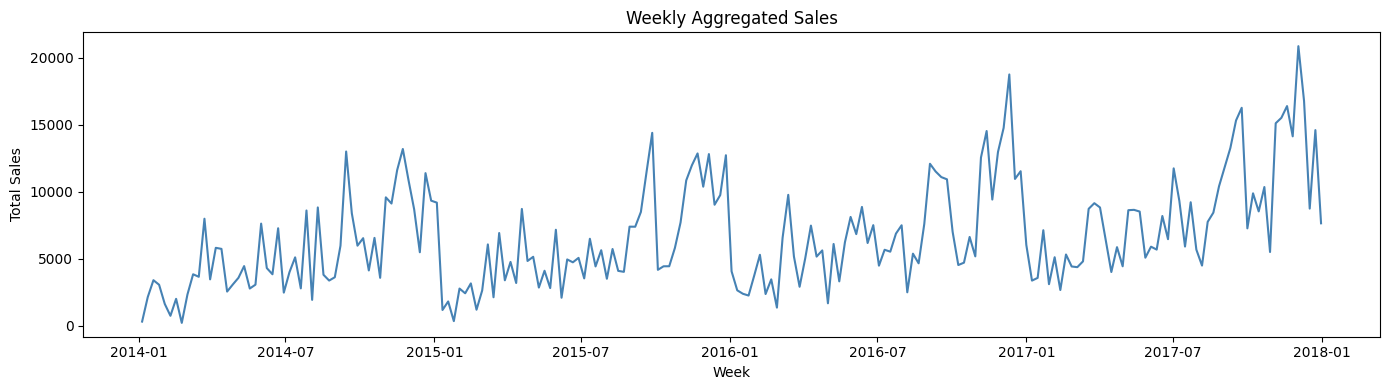

In [16]:
plt.figure(figsize=(14, 4))
plt.plot(df_ts['Week'], df_ts['Sales'], linewidth=1.5, color='steelblue')
plt.title('Weekly Aggregated Sales')
plt.xlabel('Week')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

## 9. Data Normalization

MinMaxScaler on `Sales` for modeling.  
StandardScaler on exogenous regressors (`Quantity`, `Revenue`).  
Scalers are saved for inverse-transforming predictions.

In [17]:
target_scaler = MinMaxScaler()
exog_scaler   = StandardScaler()

df_ts['Sales_scaled'] = target_scaler.fit_transform(df_ts[['Sales']])

exog_cols = ['Quantity', 'Revenue']
df_ts[[f'{c}_scaled' for c in exog_cols]] = exog_scaler.fit_transform(df_ts[exog_cols])

print('Normalization complete.')
print(df_ts[['Week','Sales','Sales_scaled']].head())

Normalization complete.
        Week     Sales  Sales_scaled
0 2014-01-05  324.0440        0.0047
1 2014-01-12 2156.6020        0.0934
2 2014-01-19 3413.7370        0.1543
3 2014-01-26 3072.3780        0.1377
4 2014-02-02 1642.3100        0.0685


## 10. Stationarity Analysis

ADF and KPSS tests determine the differencing order `d` for SARIMA.

In [18]:
def stationarity_report(series: pd.Series, label: str):
    adf_result  = adfuller(series.dropna(), autolag='AIC')
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'--- {label} ---')
    print(f'  ADF  stat={adf_result[0]:.4f}  p={adf_result[1]:.4f}  '
          f'  -> {"Stationary" if adf_result[1] < 0.05 else "Non-stationary"}')
    print(f'  KPSS stat={kpss_result[0]:.4f}  p={kpss_result[1]:.4f}  '
          f'  -> {"Stationary" if kpss_result[1] >= 0.05 else "Non-stationary"}')

stationarity_report(df_ts['Sales_scaled'], 'Sales (scaled)')

# First-order differenced
stationarity_report(df_ts['Sales_scaled'].diff().dropna(), 'Sales (1st diff)')

--- Sales (scaled) ---
  ADF  stat=-4.6826  p=0.0001    -> Stationary
  KPSS stat=0.9946  p=0.0100    -> Non-stationary
--- Sales (1st diff) ---
  ADF  stat=-7.4019  p=0.0000    -> Stationary
  KPSS stat=0.0549  p=0.1000    -> Stationary


## 11. Seasonal Decomposition

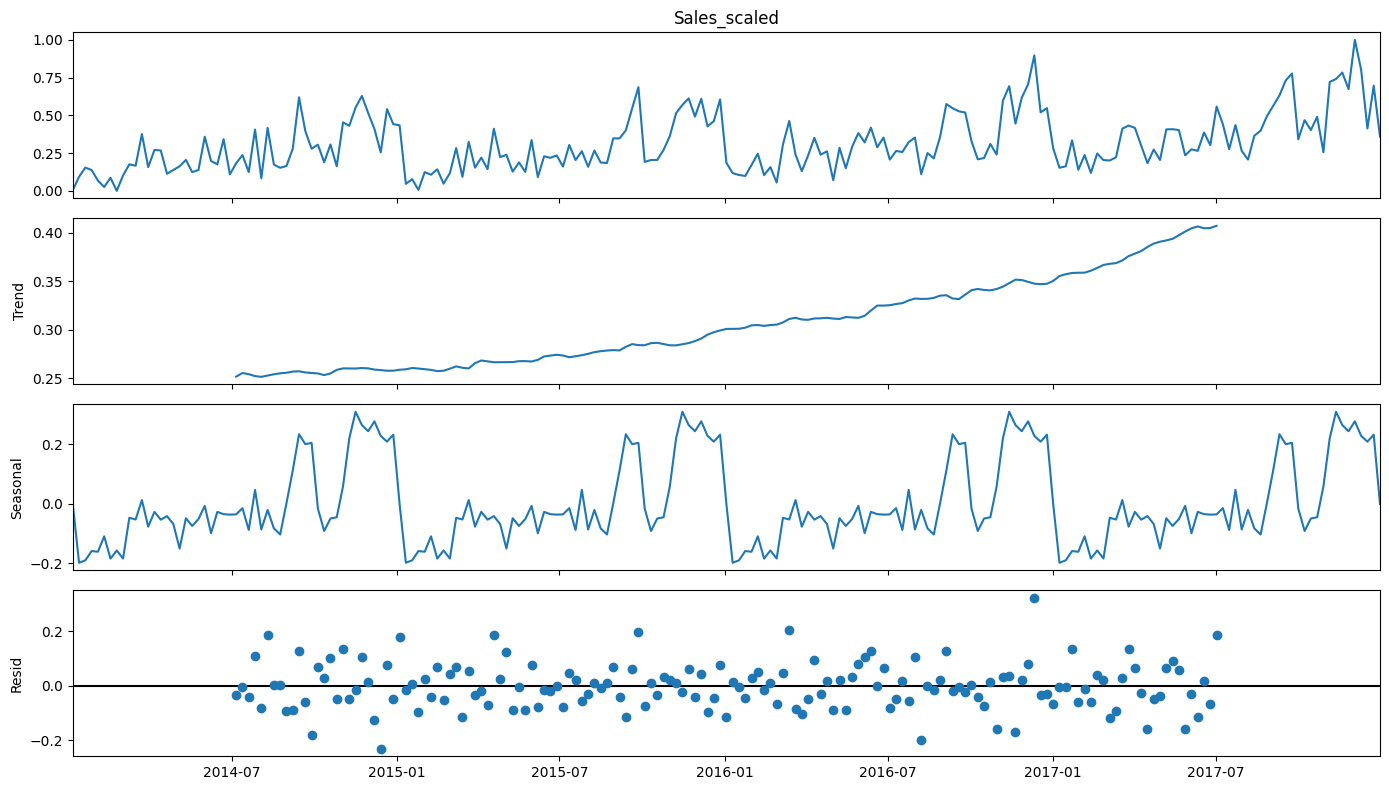

In [19]:
decomp = seasonal_decompose(df_ts.set_index('Week')['Sales_scaled'],
                             model='additive', period=52)
fig = decomp.plot()
fig.set_size_inches(14, 8)
plt.tight_layout()
plt.show()

### ACF / PACF Plots

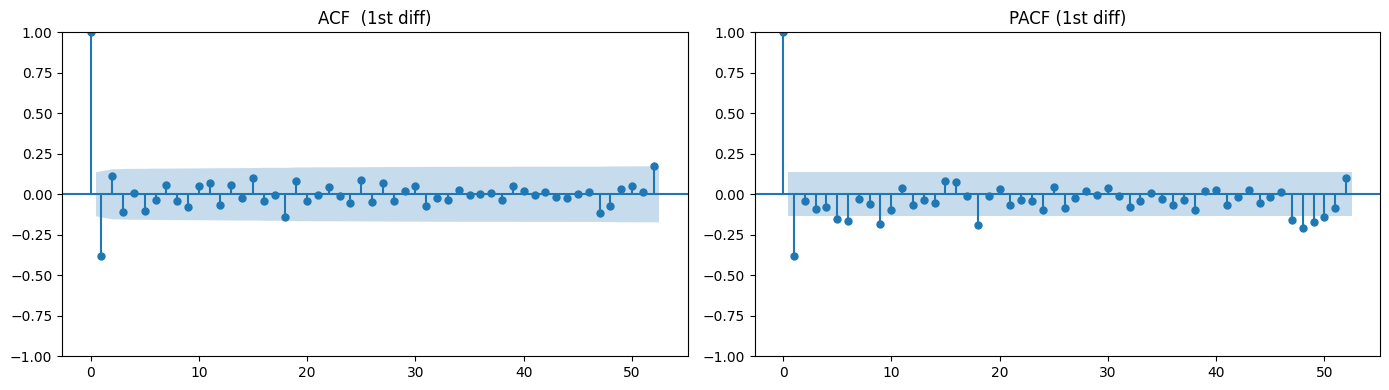

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df_ts['Sales_scaled'].diff().dropna(),  lags=52, ax=axes[0], title='ACF  (1st diff)')
plot_pacf(df_ts['Sales_scaled'].diff().dropna(), lags=52, ax=axes[1], title='PACF (1st diff)')
plt.tight_layout()
plt.show()

## 12. Train / Test Split (80 : 20)

In [21]:
split_idx = int(len(df_ts) * 0.80)

train = df_ts.iloc[:split_idx].copy()
test  = df_ts.iloc[split_idx:].copy()

print(f'Train: {len(train)} weeks  ({train["Week"].min().date()} → {train["Week"].max().date()})')
print(f'Test : {len(test)}  weeks  ({test["Week"].min().date()}  → {test["Week"].max().date()})')

Train: 167 weeks  (2014-01-05 → 2017-03-12)
Test : 42  weeks  (2017-03-19  → 2017-12-31)


## 13. Automatic SARIMA Order Selection (auto_arima)

`pmdarima.auto_arima` performs a stepwise search over `(p,d,q)(P,D,Q,m=52)` minimising AIC.  
Set `seasonal=True` and `m=52` for weekly seasonality.

In [22]:
print('Running auto_arima — this may take 1-3 minutes...')

auto_model = pm.auto_arima(
    train['Sales_scaled'],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,              # auto-detect differencing
    seasonal=True,
    m=52,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    information_criterion='aic',
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print('\nBest order    :', auto_model.order)
print('Best seasonal :', auto_model.seasonal_order)

Running auto_arima — this may take 1-3 minutes...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=-154.646, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=-187.017, Time=0.69 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=-193.047, Time=0.83 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=-156.633, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=-179.947, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[52] intercept   : AIC=-193.816, Time=1.41 sec
 ARIMA(0,1,1)(1,0,0)[52] intercept   : AIC=-195.602, Time=0.97 sec
 ARIMA(0,1,1)(2,0,0)[52] intercept   : AIC=-193.816, Time=38.39 sec
 ARIMA(0,1,1)(2,0,1)[52] intercept   : AIC=-191.816, Time=58.24 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=-155.887, Time=0.64 sec
 ARIMA(1,1,1)(1,0,0)[52] intercept   : AIC=inf, Time=1.94 sec
 ARIMA(0,1,2)(1,0,0)[52] intercept   : AIC=-194.765, Time=1.84 sec
 ARIMA(1,1,2)(1,0,0)[52] intercept   : AIC=-191.619, Time=1.29 sec
 ARIMA(0,1,1)(1,0,0)[52]             : 

## 14. Fit SARIMA Model

In [23]:
order          = auto_model.order
seasonal_order = auto_model.seasonal_order

sarima_model = SARIMAX(
    train['Sales_scaled'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                        Sales_scaled   No. Observations:                  167
Model:             SARIMAX(2, 1, 1)x(1, 0, [], 52)   Log Likelihood                  72.390
Date:                             Wed, 17 Jun 2026   AIC                           -134.781
Time:                                     22:06:03   BIC                           -121.188
Sample:                                          0   HQIC                          -129.266
                                             - 167                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1990      0.271     -0.735      0.463      -0.730       0.332
ar.L2         -0.0769      

## 15. Model Diagnostics

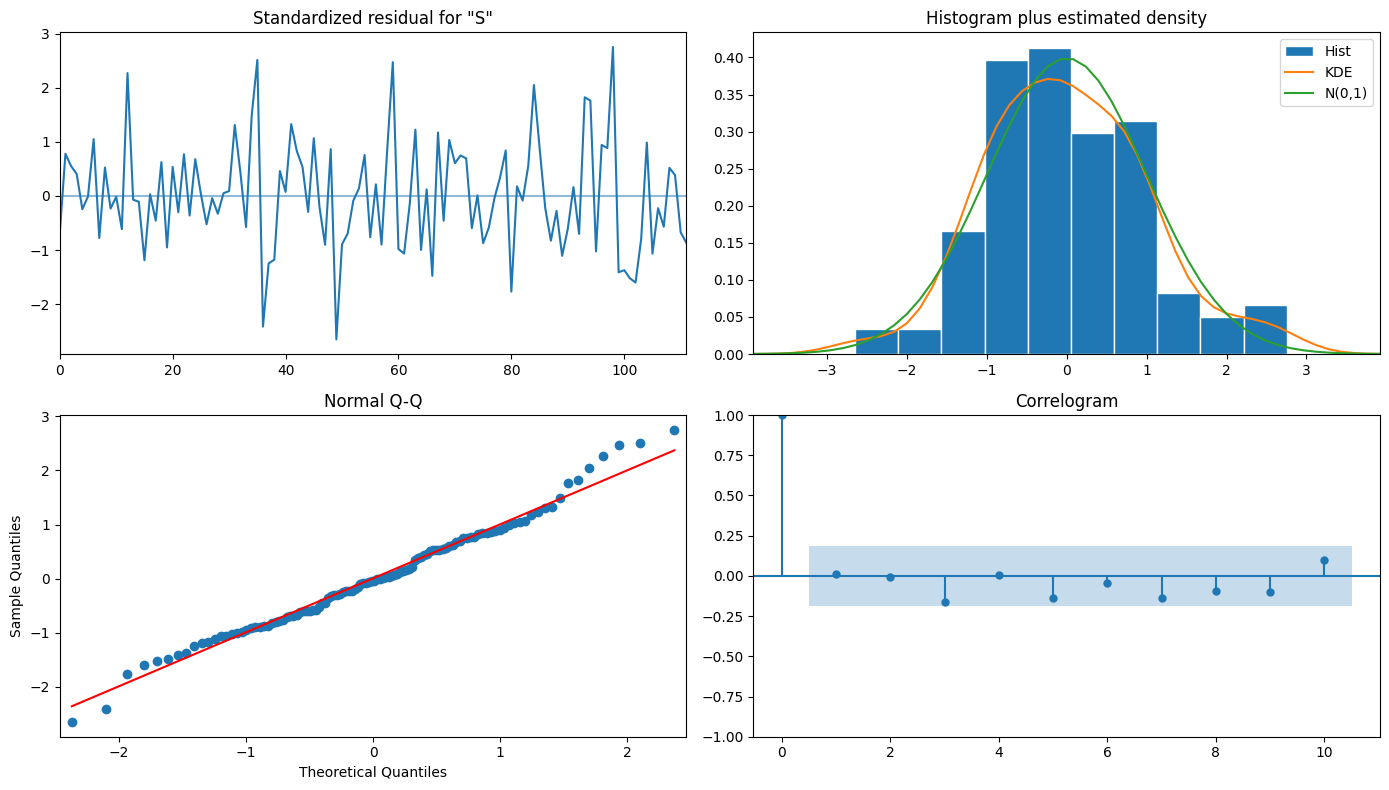

In [24]:
sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.tight_layout()
plt.show()

## 16. Forecast on Test Set

In [25]:
n_forecast = len(test)
forecast_result = sarima_fit.get_forecast(steps=n_forecast)
forecast_mean   = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int(alpha=0.05)

# Inverse-transform back to original Sales scale
forecast_sales  = target_scaler.inverse_transform(forecast_mean.values.reshape(-1, 1)).flatten()
actual_sales    = test['Sales'].values

ci_lower = target_scaler.inverse_transform(
    conf_int.iloc[:, 0].values.reshape(-1, 1)).flatten()
ci_upper = target_scaler.inverse_transform(
    conf_int.iloc[:, 1].values.reshape(-1, 1)).flatten()

print('Forecast complete.')

Forecast complete.


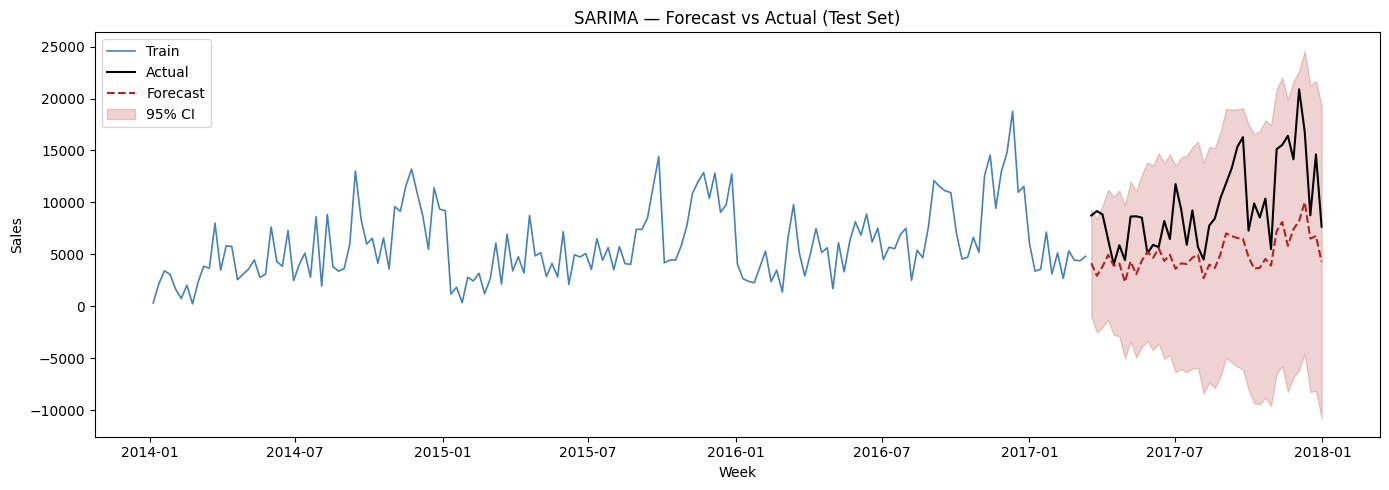

In [26]:
plt.figure(figsize=(14, 5))
plt.plot(train['Week'], target_scaler.inverse_transform(
             train['Sales_scaled'].values.reshape(-1, 1)),
         label='Train', color='steelblue', linewidth=1.2)
plt.plot(test['Week'], actual_sales,
         label='Actual', color='black', linewidth=1.5)
plt.plot(test['Week'], forecast_sales,
         label='Forecast', color='firebrick', linewidth=1.5, linestyle='--')
plt.fill_between(test['Week'], ci_lower, ci_upper,
                 alpha=0.2, color='firebrick', label='95% CI')
plt.title('SARIMA — Forecast vs Actual (Test Set)')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 17. Model Evaluation

In [27]:
mae  = mean_absolute_error(actual_sales, forecast_sales)
rmse = np.sqrt(mean_squared_error(actual_sales, forecast_sales))
mape = mean_absolute_percentage_error(actual_sales, forecast_sales) * 100

# SMAPE
smape = np.mean(
    2 * np.abs(actual_sales - forecast_sales) /
    (np.abs(actual_sales) + np.abs(forecast_sales) + 1e-8)
) * 100

# Directional accuracy
actual_dir   = np.sign(np.diff(actual_sales))
forecast_dir = np.sign(np.diff(forecast_sales))
directional_acc = np.mean(actual_dir == forecast_dir) * 100

results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'SMAPE (%)', 'Directional Accuracy (%)'],
    'Value' : [mae, rmse, mape, smape, directional_acc]
})

print(results.to_string(index=False))

                  Metric     Value
                     MAE 4640.6197
                    RMSE 5499.7413
                MAPE (%)   43.7591
               SMAPE (%)   59.0179
Directional Accuracy (%)   46.3415


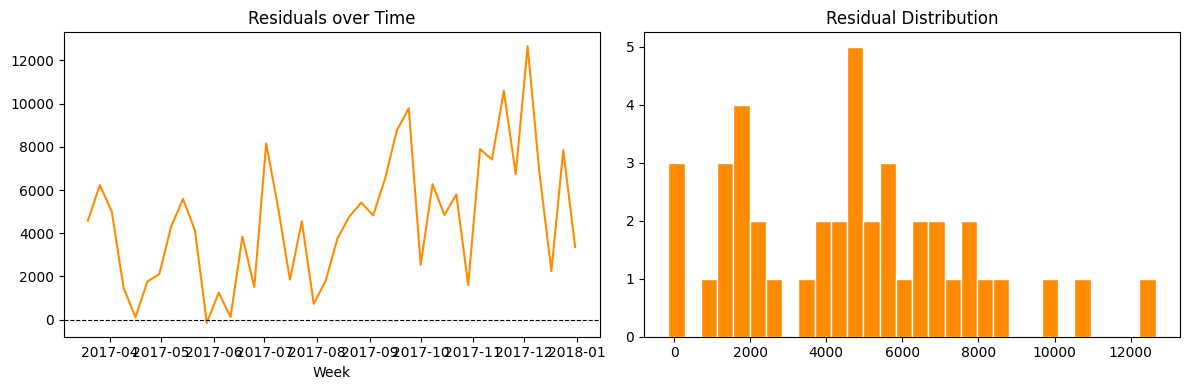

In [28]:
# Residual analysis
residuals = actual_sales - forecast_sales

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(test['Week'], residuals, color='darkorange')
axes[0].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[0].set_title('Residuals over Time')
axes[0].set_xlabel('Week')

axes[1].hist(residuals, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Residual Distribution')
plt.tight_layout()
plt.show()

## 18. Future Demand Forecast (Next 12 Weeks)

In [29]:
N_FUTURE = 12

# Refit on full dataset for future forecasting
sarima_full = SARIMAX(
    df_ts['Sales_scaled'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

future_result = sarima_full.get_forecast(steps=N_FUTURE)
future_mean   = future_result.predicted_mean
future_ci     = future_result.conf_int(alpha=0.05)

future_sales  = target_scaler.inverse_transform(future_mean.values.reshape(-1, 1)).flatten()
future_lower  = target_scaler.inverse_transform(future_ci.iloc[:, 0].values.reshape(-1, 1)).flatten()
future_upper  = target_scaler.inverse_transform(future_ci.iloc[:, 1].values.reshape(-1, 1)).flatten()

last_week   = df_ts['Week'].iloc[-1]
future_dates = pd.date_range(start=last_week + pd.Timedelta(weeks=1), periods=N_FUTURE, freq='W')

df_future = pd.DataFrame({
    'Week'         : future_dates,
    'Forecast_Sales': future_sales,
    'Lower_95'     : future_lower,
    'Upper_95'     : future_upper
})

print(df_future.to_string(index=False))

      Week  Forecast_Sales  Lower_95   Upper_95
2018-01-07       7334.7830 2318.4354 12351.1305
2018-01-14       7431.8159 2372.0515 12491.5803
2018-01-21       9877.1815 4782.7624 14971.6007
2018-01-28       7174.8337 2063.5023 12286.1651
2018-02-04       8527.8671 3400.7680 13654.9663
2018-02-11       6885.2525 1743.0470 12027.4580
2018-02-18       8664.5745 3507.3857 13821.7634
2018-02-25       8064.2895 2892.1895 13236.3895
2018-03-04       8029.4707 2842.5073 13216.4341
2018-03-11       8321.0530 3119.2701 13522.8359
2018-03-18      10953.9705 5737.4104 16170.5305
2018-03-25      11236.6343 6005.3390 16467.9296


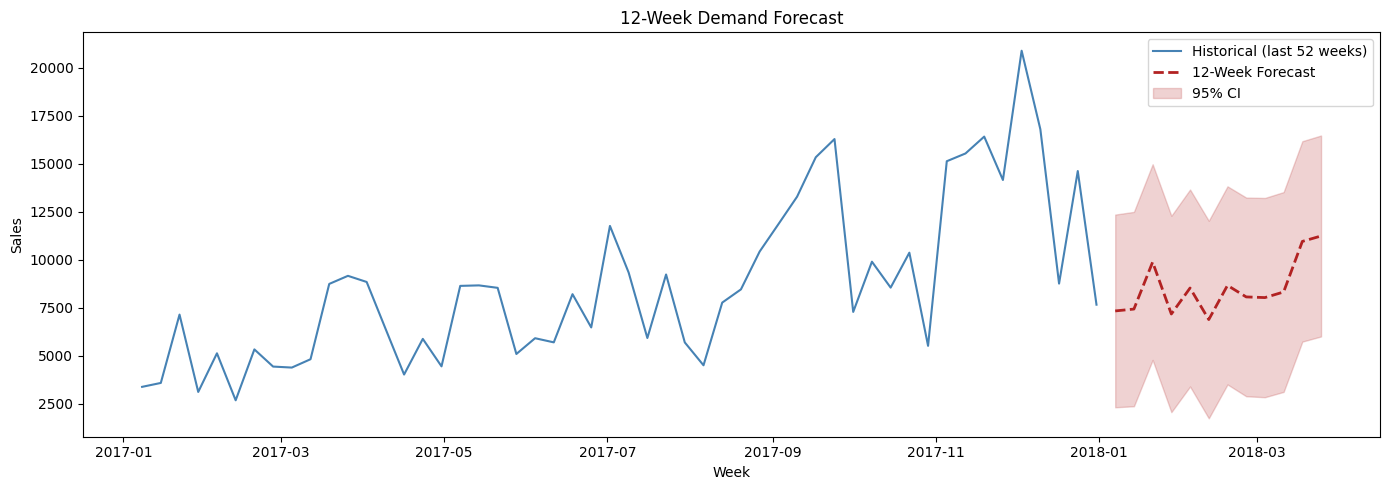

In [30]:
plt.figure(figsize=(14, 5))
recent = df_ts.tail(52)
plt.plot(recent['Week'],
         target_scaler.inverse_transform(recent['Sales_scaled'].values.reshape(-1,1)),
         label='Historical (last 52 weeks)', color='steelblue')
plt.plot(df_future['Week'], df_future['Forecast_Sales'],
         label='12-Week Forecast', color='firebrick', linewidth=2, linestyle='--')
plt.fill_between(df_future['Week'], df_future['Lower_95'], df_future['Upper_95'],
                 alpha=0.2, color='firebrick', label='95% CI')
plt.title('12-Week Demand Forecast')
plt.xlabel('Week')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 19. Export Processed Data & Forecast

In [31]:
# Processed feature-engineered dataset
df.to_csv('processed_retail_data.csv', index=False)

# Weekly aggregated time-series
df_ts.to_csv('weekly_sales_timeseries.csv', index=False)

# Future forecast
df_future.to_csv('forecast_next_12_weeks.csv', index=False)

print('Exported:')
print('  processed_retail_data.csv')
print('  weekly_sales_timeseries.csv')
print('  forecast_next_12_weeks.csv')

Exported:
  processed_retail_data.csv
  weekly_sales_timeseries.csv
  forecast_next_12_weeks.csv
